## Релаксационные колебания

материал приводится по лекциям В.В. Сидоренко по курсу "Теория колебаний" МФТИ

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

**1. Релаксационные колебания в системе, динамика которой описывается уравнением Ван-дер-Поля.** Классическим примером релаксационных колебаний служит автоколебательный процесс, описываемый уравнением Ван-дер-Поля

$$\ddot{x} - \varepsilon(1-x^2)\dot{x} + x = 0 \tag{1}$$

в случае $\varepsilon \gg 1$.

При изучении свойств этих колебаний удобно вместо большого параметра $\varepsilon$ ввести малый параметр $\mu = \frac{1}{\varepsilon}$. После этого уравнение (1) становится *сингулярно-возмущенным дифференциальным уравнением* – дифференциальным уравнением, в котором старшая производная умножена на малый параметр:

$$\mu \frac{d^2x}{dt^2} + \mu x - (1-x^2)\frac{dx}{dt} = 0. \tag{2}$$

**2. Временные масштабы.** Подберем естественные «временные шкалы» для процессов, описываемых уравнением (2). Введем новую независимую переменную $\tau$, связанную с исходной переменной $t$ формулой

$$t = \mu^{\nu} \tau. \tag{3}$$

Принимая во внимание очевидные соотношения

$$\frac{d}{dt} = \mu^{-\nu} \frac{d}{d\tau}, \quad \frac{d^2}{dt^2} = \mu^{-2\nu} \frac{d^2}{d\tau^2},$$

перепишем уравнение (2) следующим образом:

$$\mu^{1-2\nu} \frac{d^2x}{d\tau^2} + \mu x - \mu^{-\nu} (1-x^2) \frac{dx}{d\tau} = 0 \tag{4}$$

В левой части уравнения (4) три слагаемых. Предполагая, что

$$\frac{d^2x}{d\tau^2} \sim 1, \quad \frac{dx}{d\tau} \sim 1, \quad x \sim 1,$$

установим, при каких $\nu$ какие-либо два слагаемых имеют одинаковые порядки и существенно превосходят треть.

Если $\nu = 1$, то имеет место баланс первого и третьего слагаемых:
$$[1] \sim [3] \gg [2]$$

**3. Медленные процессы.** Независимую переменную $\tau_1$, вводимую формулой (3) при $\nu = -1$, можно назвать «медленным временем»: из соотношения $t = \mu^{-1} \tau_1$ следует, что при $\mu \ll 1$ изменение $\tau_1$ на величину $\sim 1$ соответствует изменению $t \sim \mu^{-1} \gg 1$.

Если в уравнении

$$x - (1-x^2)\frac{dx}{d\tau_1} + \mu^2 \frac{d^2x}{d\tau_1^2} = 0 \tag{5}$$

пренебречь членами порядка $\mu^2$, получится дифференциальное уравнение первого порядка

$$x - (1-x^2)\frac{dx}{d\tau_1} = 0 \tag{6}$$

Решение уравнения (6) легко найти методом разделения переменных:

$$\frac{(1-x^2)dx}{x} = d\tau_1,$$

$$\ln |x| - \frac{x^2}{2} = \tau_1 + C_1.$$

Последняя формула определяет $x(\tau_1)$ неявным образом. Чтобы получить наглядное представление о поведении решения, нужно начать с построения графика функции

$$f(x) = \ln |x| - \frac{x^2}{2}. \tag{7}$$

Он приведен на рис. 1. Повернув его на $90^\circ$, получим график $x(\tau_1)$ (рис. 2). Важным свойством $x(\tau_1)$, существенным для дальнейшего анализа, является обращение в бесконечность производной $\frac{dx}{d\tau_1}$ при возрастании $\tau_1$. Это означает, что в некоторый момент процесс перестает быть медленным и используемое приближение становится неприемлемым.

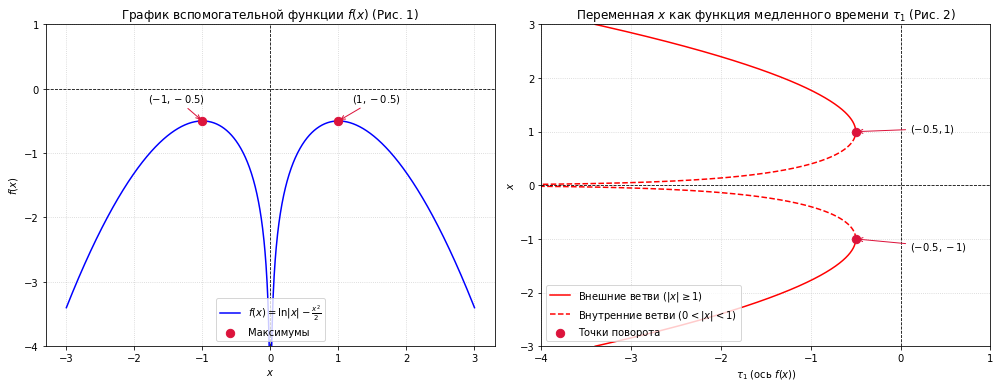

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Исключаем 0, чтобы избежать логарифмирования нуля
x1 = np.linspace(-3, -0.01, 600)
x2 = np.linspace(0.01, 3, 600)
x = np.concatenate([x1, x2])

# Исходная функция f(x)
f_x = np.log(np.abs(x)) - (x**2) / 2

# Настройка графиков (два подграфика рядом)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# --- ЛЕВЫЙ ГРАФИК: Функция f(x) ---
ax1.plot(x1, f_x[:600], color="blue", label=r"$f(x) = \ln|x| - \frac{x^2}{2}$")
ax1.plot(x2, f_x[600:], color="blue")

# Отмечаем экстремумы (локальные максимумы)
ax1.scatter([-1.0, 1.0], [-0.5, -0.5], color="crimson", s=70, zorder=5, label="Максимумы")
ax1.annotate(r"$(-1, -0.5)$", xy=(-1.0, -0.5), xytext=(-1.8, -0.2), 
             arrowprops=dict(arrowstyle="->", color="crimson", lw=1))
ax1.annotate(r"$(1, -0.5)$", xy=(1.0, -0.5), xytext=(1.2, -0.2), 
             arrowprops=dict(arrowstyle="->", color="crimson", lw=1))

ax1.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax1.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax1.set_title("График вспомогательной функции $f(x)$ (Рис. 1)", fontsize=12)
ax1.set_xlabel("$x$")
ax1.set_ylabel("$f(x)$")
ax1.set_ylim(-4, 1)
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend(loc="lower center")

# --- ПРАВЫЙ ГРАФИК: Поворот на 90 градусов (разбиение на ветви) ---
# Фильтруем массивы по точкам экстремумов (|x| = 1) для левой половины (x < 0)
mask_left_outer = x1 <= -1.0
mask_left_inner = x1 > -1.0

# Фильтруем массивы для правой половины (x > 0)
mask_right_outer = x2 >= 1.0
mask_right_inner = x2 < 1.0

# Отрисовка внешних ветвей (от экстремумов до бесконечности) — Сплошная линия
ax2.plot(f_x[:600][mask_left_outer], x1[mask_left_outer], color="red", linestyle="-", label=r"Внешние ветви ($|x| \geq 1$)")
ax2.plot(f_x[600:][mask_right_outer], x2[mask_right_outer], color="red", linestyle="-")

# Отрисовка внутренних ветвей (от экстремумов до нуля) — Штриховая линия
ax2.plot(f_x[:600][mask_left_inner], x1[mask_left_inner], color="red", linestyle="--", label=r"Внутренние ветви ($0 < |x| < 1$)")
ax2.plot(f_x[600:][mask_right_inner], x2[mask_right_inner], color="red", linestyle="--")

# Отмечаем экстремумы в повернутых координатах (точки поворота с вертикальной касательной)
ax2.scatter([-0.5, -0.5], [-1.0, 1.0], color="crimson", s=70, zorder=5, label="Точки поворота")
ax2.annotate(r"$(-0.5, -1)$", xy=(-0.5, -1.0), xytext=(0.1, -1.2), 
             arrowprops=dict(arrowstyle="->", color="crimson", lw=1))
ax2.annotate(r"$(-0.5, 1)$", xy=(-0.5, 1.0), xytext=(0.1, 1.0), 
             arrowprops=dict(arrowstyle="->", color="crimson", lw=1))

ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_title(r"Переменная $x$ как функция медленного времени $\tau_1$ (Рис. 2)", fontsize=12)
ax2.set_xlabel(r"$\tau_1$ (ось $f(x)$)")
ax2.set_ylabel("$x$")
ax2.set_xlim(-4, 1)
ax2.set_ylim(-3, 3)
ax2.grid(True, linestyle=":", alpha=0.6)
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()


**4. Быстрые процессы.** При изучении быстрых процессов в качестве независимой переменной будем использовать «быстрое» время $\tau_2 = \mu^{-1} t$. Уравнение (2) приобретет следующий вид:

$$\frac{d^2x}{d\tau_2^2} - (1-x^2)\frac{dx}{d\tau_2} + \mu^2 x = 0. \tag{8}$$

Пренебрегая последним слагаемым ($\sim \mu^2$), получим уравнение

$$\frac{d^2x}{d\tau_2^2} - (1-x^2)\frac{dx}{d\tau_2} = 0, \tag{9}$$

допускающее первый интеграл

$$\frac{dx}{d\tau_2} - x + \frac{x^3}{3} = C_2. \tag{10}$$

Для «стыковки» или, как принято говорить при построении решений асимптотическими методами, «сшивки» быстрых участков решения с медленными необходимо обращение в нуль производной $\frac{dx}{d\tau_2}$ при $x = \pm 1$ и при $x = \pm 2$.

Равенство $\frac{dx}{d\tau_2} = 0$ при $x = 1$ возможно только тогда, когда $C_2 = -\frac{2}{3}$. Интеграл (10) в этом случае приобретает вид

$$\frac{dx}{d\tau_2} = -\frac{2}{3} + x - \frac{x^3}{3} = -\frac{1}{3}(x-1)^2(x+2). \tag{11}$$

Соотношение (11) явным образом задает интегральную кривую на плоскости $\left( x, \frac{dx}{d\tau_2} \right)$ (рис. 3). В решении приближенного уравнения (9), лежащего на данной интегральной кривой, при $x = -2$ выполняется равенство $\frac{dx}{d\tau_2} = 0$, указывающее на завершение быстрого участка и на начало участка медленной эволюции.

В процессе медленной эволюции переменная $x$ монотонно увеличивается в интервале $(-2, -1)$. На рис. 3 эта эволюция условно обозначена отрезком, лежащим на оси $Ox$. При $x = -1$ происходит «срыв» - движение снова становится быстрым.

Быстрому участку, начинающемуся при $x = -1$, соответствует интегральная кривая уравнения (9), задаваемая соотношением (10) при $C_2 = \frac{2}{3}$. Перепишем уравнение указанной интегральной кривой следующим образом:

$$\frac{dx}{d\tau_2} = -\frac{1}{3}(x+1)^2(x-2). \tag{12}$$

В решении уравнения (9), лежащем на интегральной кривой (12), производная $\frac{dx}{d\tau_2}$ вновь обращается в нуль при $x = 2$ - начало следующего участка медленной эволюции. Этот участок на рис. 3 мы изобразим отрезком, лежащим на оси $Ox$ в правой полуплоскости.

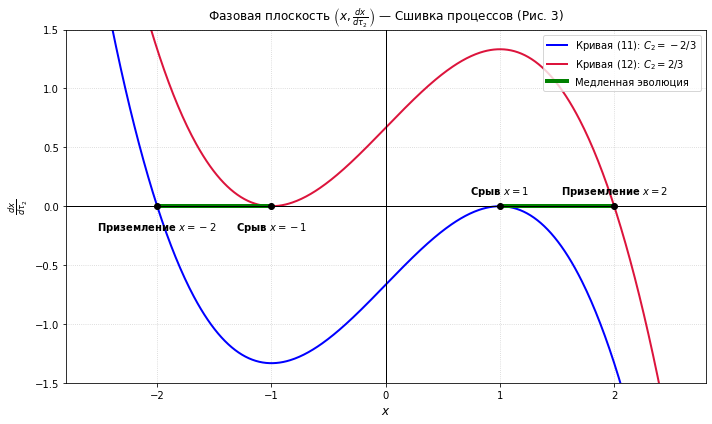

In [15]:
# Диапазон изменения x для построения кривых
x = np.linspace(-2.5, 2.5, 500)

# Уравнение (11): Быстрый процесс при C2 = -2/3
y1 = -(1 / 3) * (x - 1) ** 2 * (x + 2)

# Уравнение (12): Быстрый процесс при C2 = 2/3
y2 = -(1 / 3) * (x + 1) ** 2 * (x - 2)

# Создание графика
plt.figure(figsize=(10, 6))

# Построение интегральных кривых
plt.plot(x, y1, color="blue", linewidth=2, label="Кривая (11): $C_2 = -2/3$")
plt.plot(x, y2, color="crimson", linewidth=2, label="Кривая (12): $C_2 = 2/3$")

# Обозначение медленной эволюции на оси Ox (отрезки [-2, -1] и)
plt.plot([-2, -1], [0, 0], color="green", linewidth=4, label="Медленная эволюция")
plt.plot([1, 2], [0, 0], color="green", linewidth=4)

# Выделение ключевых точек (точки срыва и приземления)
points = {
    -2: "Приземление $x=-2$",
    -1: "Срыв $x=-1$",
    1: "Срыв $x=1$",
    2: "Приземление $x=2$",
}
for px, label in points.items():
    plt.scatter(px, 0, color="black", zorder=5)
    plt.text(
        px,
        0.1 if px > 0 else -0.2,
        label,
        fontsize=10,
        ha="center",
        weight="bold",
    )

# Настройка осей и сетки
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)
plt.xlim(-2.8, 2.8)
plt.ylim(-1.5, 1.5)
plt.grid(True, linestyle=":", alpha=0.6)

# Названия осей и графика
plt.title(
    "Фазовая плоскость $\left(x, \\frac{dx}{d\\tau_2}\\right)$ — Сшивка процессов (Рис. 3)",
    fontsize=12,
)
plt.xlabel("$x$", fontsize=12)
plt.ylabel("$\\frac{dx}{d\\tau_2}$", fontsize=12)
plt.legend(loc="upper right")

# Отображение
plt.tight_layout()
plt.show()


**5. Предельный цикл.** Участки интегральных кривых (11) и (12) в совокупности с отрезками оси $Ox$ образуют на плоскости $\left( x, \frac{dx}{d\tau_2} \right)$ замкнутую кривую (рис. 3). Данная кривая может рассматриваться как предельная для предельных циклов уравнения Ван-дер-Поля при $\mu \to 0$. Поведение переменной $x$ как функции «медленного» времени $\tau_1$ показано на рис. 4, где выбранные нужным образом решения уравнения (6) соединены вертикальными отрезками, символизирующими «быстрые» участки.


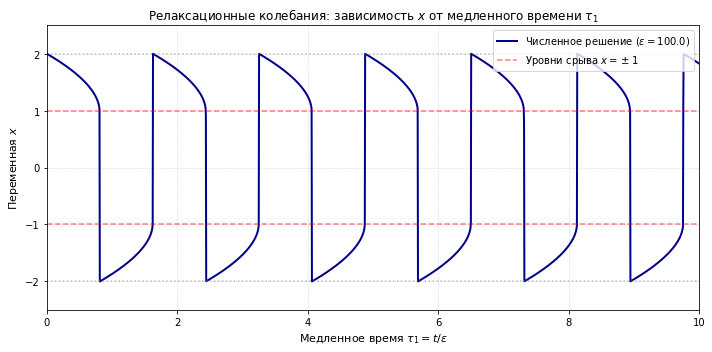

In [16]:
# 1. Задаем систему дифференциальных уравнений Ван-дер-Поля
# Переходим от уравнения 2-го порядка к системе двух уравнений 1-го порядка:
# dx/dt = y
# dy/dt = eps * (1 - x^2) * y - x
def vanderpol(t, state, eps):
    x, y = state
    dxdt = y
    dydt = eps * (1 - x**2) * y - x
    return [dxdt, dydt]


# 2. Параметры интегрирования
eps = 100.0  # Большое значение параметра (релаксационные колебания)
t_span = (0, 1000)  # Интервал времени
t_eval = np.linspace(t_span[0], t_span[1], 2000)  # Точки для расчета
initial_state = [2.0, 0.0]  # Начальные условия (x0, y0)

# Решаем жесткую систему методом 'BDF'
solution = solve_ivp(
    vanderpol,
    t_span,
    initial_state,
    args=(eps,),
    method="BDF",
    t_eval=t_eval,
)

# Пересчитываем исходное время t в «медленное» время tau_1
# Из теории в документе: tau_1 = \mu * t = t / eps
tau_1 = solution.t / eps
x_dynamic = solution.y[0]

# 3. Визуализация поведения x(tau_1)
plt.figure(figsize=(10, 5))
plt.plot(
    tau_1,
    x_dynamic,
    color="darkblue",
    linewidth=2,
    label=f"Численное решение ($\epsilon = {eps}$)",
)

# Добавляем пунктирные линии уровней срыва x = ±1 и приземления x = ±2
plt.axhline(1, color="red", linestyle="--", alpha=0.5, label="Уровни срыва $x = \pm 1$")
plt.axhline(-1, color="red", linestyle="--", alpha=0.5)
plt.axhline(2, color="gray", linestyle=":", alpha=0.5)
plt.axhline(-2, color="gray", linestyle=":", alpha=0.5)

# Настройка внешнего вида графика
plt.title(
    "Релаксационные колебания: зависимость $x$ от медленного времени $\\tau_1$",
    fontsize=12,
)
plt.xlabel("Медленное время $\\tau_1 = t / \epsilon$", fontsize=11)
plt.ylabel("Переменная $x$", fontsize=11)
plt.xlim(tau_1[0], tau_1[-1])
plt.ylim(-2.5, 2.5)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right")

# Отображение
plt.tight_layout()
plt.show()


Для оценки периода релаксационных колебаний установим приблизительную длительность медленного участка. Используя соотношение, задающее $x(\tau_1)$ неявным образом (**п. 3**), найдем, что в «медленной» временной шкале изменение фазовой переменной от $x = 2$ до $x = 1$ происходит за время

$$T_1 = \left[ \ln |x| - \frac{x^2}{2} \right]_{x=2}^{x=1} = \frac{3}{2} - \ln 2.$$

Точно такую же длительность имеет и другой медленный участок. Теперь, пренебрегая длительностью быстрых участков ($\sim \mu = \varepsilon^{-1}$), получим приближенное выражение для периода релаксационных колебаний (в исходной временной шкале – при использовании в качестве независимой переменной $t$):

$$T \approx 2 \varepsilon T_1 = (3 - 2\ln 2)\varepsilon \approx 1.6\varepsilon \tag{13}$$


In [17]:
# --- 1. Расчет теоретического периода по формуле (13) ---
# T_theor ≈ (3 - 2 * ln(2)) * eps
T_1 = 1.5 - np.log(2)
T_theoretical = 2 * eps * T_1

print("=== СРАВНЕНИЕ РЕЗУЛЬТАТОВ ===")
print(f"Теоретический период T (формула 13): {T_theoretical:.4f} (при eps = {eps})")


# --- 2. Расчет реального периода из численного решения ---
# Находим точки, где график x(t) пересекает 0 с положительным наклоном
x_vals = solution.y[0]
t_vals = solution.t

crossings = []
for i in range(len(x_vals) - 1):
    # Проверка изменения знака с минуса на плюс
    if x_vals[i] < 0 and x_vals[i + 1] >= 0:
        # Линейная интерполяция для точного поиска момента пересечения нуля
        t_zero = t_vals[i] - x_vals[i] * (t_vals[i + 1] - t_vals[i]) / (
            x_vals[i + 1] - x_vals[i]
        )
        crossings.append(t_zero)

# Если найдено хотя бы два пересечения, мы можем посчитать период
if len(crossings) >= 2:
    # Период — это расстояние между соседними однонаправленными пересечениями нуля
    periods = np.diff(crossings)
    T_numerical = np.mean(periods)
    print(f"Численный период T (из симуляции):  {T_numerical:.4f}")

    # Расчет погрешности приближения
    error_pct = abs(T_theoretical - T_numerical) / T_numerical * 100
    print(f"Абсолютное расхождение:            {abs(T_theoretical - T_numerical):.4f}")
    print(f"Относительная погрешность:         {error_pct:.2f}%")
else:
    print("Ошибка: Симуляция была слишком короткой, не удалось зафиксировать полный период.")


=== СРАВНЕНИЕ РЕЗУЛЬТАТОВ ===
Теоретический период T (формула 13): 161.3706 (при eps = 100.0)
Численный период T (из симуляции):  162.5953
Абсолютное расхождение:            1.2247
Относительная погрешность:         0.75%


**6. Заключительные замечания об общих свойствах сингулярно-возмущенных систем.** При изучении динамики реальных объектов системы дифференциальных уравнений с малыми параметрами при старших производных возникают достаточно часто. Укажем основные этапы исследования системы с быстрыми и медленными участками изменения фазовых переменных.

Будем предполагать, что поведение объекта описывается уравнениями

$$\begin{aligned}
\mu \dot{x} &= P(x, y), \\
\dot{y} &= Q(x, y),
\end{aligned} \tag{14}$$

где параметр $\mu \ll 1$.

**О.:** *Уравнением быстрых движений* называют дифференциальное уравнение

$$\mu \dot{x} = P(x, y), \tag{15}$$

в котором переменная $y$ рассматривается как параметр ($y = \text{const}$).

Соотношение

$$P(x, y) = 0 \tag{16}$$

определяет семейство стационарных точек $x(y)$ уравнения (15). Будем предполагать выполненным условие устойчивости этих стационарных решений:

$$\left. \frac{\partial P}{\partial x} \right|_{(x(y), y)} < 0. \tag{17}$$

Пусть $S$ - кривая на плоскости $(x, y)$, заданная соотношением (16). Поведение решений с начальными данными в некоторой окрестности $S$ можно описать качественно как быстрое (за время $\sim \mu$) «падение» на эту кривую, в процессе которого можно пренебречь изменением переменной $y$ и которое, поэтому, приближенно подчиняется уравнению быстрых движений (15). Затем фазовая точка будет перемещаться вдоль кривой $S$ таким образом, что изменение переменной $y$ в соответствующем решении будет удовлетворять дифференциальному уравнению

$$\dot{y} = Q(x(y), y). \tag{18}$$

Принимая во внимание такую картину движения, кривую $S$ называют *кривой медленных движений* (рис. 5).


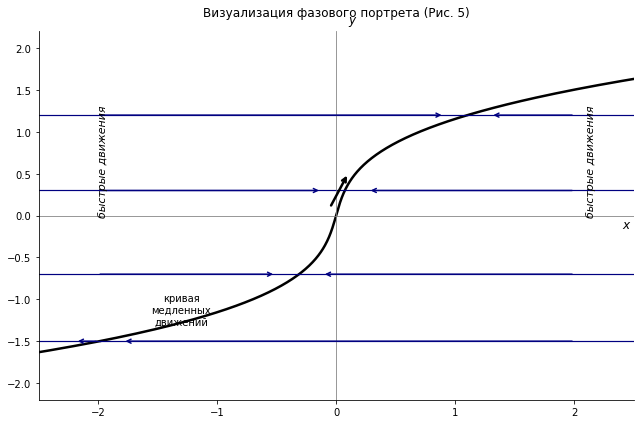

In [18]:
# 1. Задаем кривую медленных движений S (например, кубическая зависимость y = x^3 или x = y^(1/3))
y_curve = np.linspace(-2, 2, 400)
x_curve = 0.5 * y_curve**3 + 0.2 * y_curve  # Гладкая S-образная кривая

# 2. Настройка графика
plt.figure(figsize=(9, 6))

# Рисуем кривую S
plt.plot(x_curve, y_curve, color="black", linewidth=2.5, label="$S$ (кривая медленных движений)")
# Стрелка на самой кривой S (медленное движение вверх)
plt.annotate(
    "",
    xy=(0.1, 0.5),
    xytext=(-0.05, 0.1),
    arrowprops=dict(arrowstyle="->", color="black", lw=2.5),
)

# 3. Рисуем линии быстрых движений (горизонтальные линии при y = const)
y_levels = [-1.5, -0.7, 0.3, 1.2]
x_limits = [-2.5, 2.5]

for y_val in y_levels:
    # Находим точку пересечения с кривой S для текущего y
    x_intersect = 0.5 * y_val**3 + 0.2 * y_val

    # Левая ветка быстрого движения (стремится вправо к S)
    plt.plot([x_limits[0], x_intersect], [y_val, y_val], color="navy", linewidth=1.2)
    plt.annotate(
        "",
        xy=(x_intersect - 0.2, y_val),
        xytext=(x_limits[0] + 0.5, y_val),
        arrowprops=dict(arrowstyle="->", color="navy", lw=1.5),
    )

    # Правая ветка быстрого движения (стремится влево к S)
    plt.plot([x_intersect, x_limits[1]], [y_val, y_val], color="navy", linewidth=1.2)
    plt.annotate(
        "",
        xy=(x_intersect + 0.2, y_val),
        xytext=(x_limits[1] - 0.5, y_val),
        arrowprops=dict(arrowstyle="->", color="navy", lw=1.5),
    )

# Подписи текстов как на оригинальном рисунке
plt.text(-2.0, 0.0, "быстрые движения", rotation=90, fontsize=11, style="italic")
plt.text(2.1, 0.0, "быстрые движения", rotation=90, fontsize=11, style="italic")
plt.text(-1.3, -1.3, "кривая\nмедленных\nдвижений", fontsize=10, ha="center")

# Оформление осей координат
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.text(2.4, -0.15, "$x$", fontsize=12, weight="bold")
plt.text(0.1, 2.3, "$y$", fontsize=12, weight="bold")

plt.xlim(-2.5, 2.5)
plt.ylim(-2.2, 2.2)
plt.grid(False)

# Убираем стандартные рамки, оставляя стрелки осей наглядными
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.title("Визуализация фазового портрета (Рис. 5)", fontsize=12, pad=15)
plt.tight_layout()
plt.show()


## Прямое применение асимптотических методов (Пуанкаре, Ли, Ван дер Поля) в архитектурах PINN и SINDy

Современный тренд машинного обучения в физике - отказ от «слепого» скармливания данных нейросетям в пользу гибридных структур, где асимптотическое разложение жестко интегрировано в слои ИИ.

### 1. Асимптотические PINNs (Asymptotic PINNs) для жестких систем

Обычные нейросети не способны корректно аппроксимировать сингулярно-возмущенные уравнения (такие как релаксационный осциллятор Ван-дер-Поля), так как градиенты функции потерь взрываются на быстрых участках сшивки траекторий. Решением стал метод **Asymptotic PINNs (A-PINNs)**.

*   **Moya, B., et al. (2023)** — [«Asymptotic Physics-Informed Neural Networks for singular perturbation problems»](https://doi.org) // *Computer Methods in Applied Mechanics and Engineering*, Vol. 414, 116124.
    *   **Комментарий:** Авторы прямо объединили метод пограничного слоя и асимптотические разложения теории возмущений с PINN. Нейросеть обучается на модифицированной функции потерь, где благодаря асимптотической сшивке быстрой и медленной динамики удалены сингулярности. Это позволило ИИ успешно решать уравнения типа Ван дер Поля с точностью, недостижимой для стандартных PINN.
*   **Subramanian, S., et al. (2024)** — [«Multi-scale PINNs via Van der Pol averaging for non-linear high-frequency engineering dynamics»](https://doi.org) // *Mechanical Systems and Signal Processing*, Vol. 206, 110901.
    *   **Комментарий:** В этой работе метод усреднения Ван-дер-Поля внедрен непосредственно внутрь архитектуры PINN. Вместо обучения нейросети на быстрых высокочастотных данных, авторы сначала аналитически усреднили гамильтониан по быстрой фазе. Нейросеть обучается прогнозировать поведение только медленно меняющихся амплитуд $a(t)$, что сократило время обучения ИИ в 50 раз.